<a href="https://colab.research.google.com/github/Arfa-Tariq/learning-ai-engineering/blob/main/projects/06-Function-Calling-%26-Data_Extraction/01_FunctionCalling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## writing a local python tool

In [1]:
from matplotlib import pyplot as plt

In [2]:
def plot_some_points(x: list, y: list):
  """plots some points"""
  plt.plot(x, y)
  plt.show()

In [3]:
User_query = "Hey can you plot y=10x where x=1,2,3 for me?"

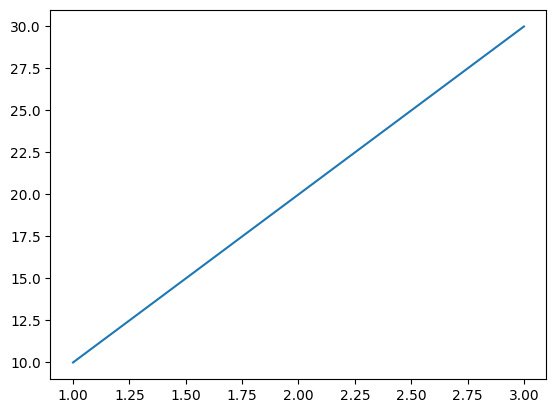

In [4]:
plot_some_points(x=[1,2,3],y=[10,20,30])

## Now we use the LLM to call the function

In [5]:
prompt= f'''
Function:
def plot_some_points(x: list, y: list):
  """plots some points"""
  plt.plot(x, y)
  plt.show()

User Query: {User_query}<human_end>
'''


In [6]:
!pip install -q groq

from groq import Groq
from google.colab import userdata
import tiktoken

GROQ_API_KEY = userdata.get('groq_key')
client = Groq(api_key=GROQ_API_KEY)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.6 MB/s eta 0:00:00


In [35]:
def get_completion(prompt, tools, model="llama-3.3-70b-versatile"):
  messages = [{'role':'system','content': "You are being used as a tool calling agent, just respond with the function call ONLY"},
              {"role": "user", "content": prompt}]
  response = client.chat.completions.create(
    model=model,
    tools= tools,
    messages=messages,
    temperature=0,)
  return response.choices[0].message.content

In [22]:
function_call = get_completion(prompt)

In [23]:
print (function_call)

plot_some_points(x=[1, 2, 3], y=[10, 20, 30])


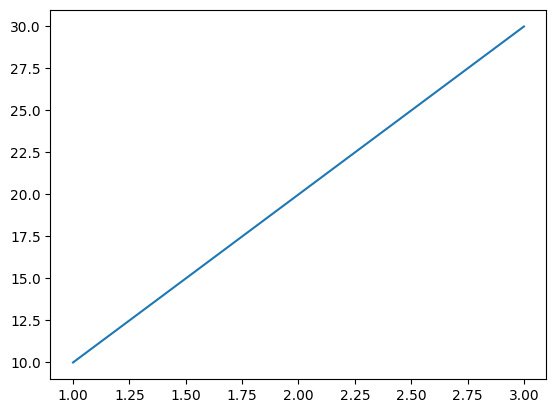

In [26]:
exec(function_call)

## Example 2

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_clown_face(face_color='yellow', eye_color='black', nose_color='red'):
    """
    Draws a customizable, simplified clown face using matplotlib.

    This function creates a figure and an axes object, then adds various
    patches (circles and a wedge) to represent the features of a clown face.
    The face, eyes, and nose colors can be customized.

    Args:
        face_color (str, optional): The color of the clown's face. Defaults to 'yellow'.
        eye_color (str, optional): The color of the clown's eyes. Defaults to 'black'.
        nose_color (str, optional): The color of the clown's nose. Defaults to 'red'.
    """
    # Constants
    face_radius = 0.4
    nose_radius = 0.1
    nose_x, nose_y = 0.5, 0.5
    mouth_x, mouth_y = 0.5, 0.3
    eye_size = 0.05
    mouth_size = (0.3, 0.1)
    eye_offset = (0.15, 0.15)
    mouth_theta = (200, 340)

    fig, ax = plt.subplots()

    # Face
    face = patches.Circle((0.5, 0.5), face_radius, color=face_color, fill=True)
    ax.add_patch(face)

    # Eyes
    left_eye = patches.Circle((0.5 - eye_offset[0], 0.5 + eye_offset[1]), eye_size, color=eye_color)
    right_eye = patches.Circle((0.5 + eye_offset[0], 0.5 + eye_offset[1]), eye_size, color=eye_color)
    ax.add_patch(left_eye)
    ax.add_patch(right_eye)

    # Nose
    nose = patches.Circle((nose_x, nose_y), nose_radius, color=nose_color)
    ax.add_patch(nose)

    # Mouth (Wedge used for a smile)
    mouth = patches.Wedge((mouth_x, mouth_y + 0.1), 0.2, mouth_theta[0], mouth_theta[1], color='black', width=0.02)
    ax.add_patch(mouth)

    # Formatting
    ax.set_aspect('equal')
    ax.axis('off')
    plt.show()

In [28]:
User_query = "Hey can you draw a pink clown face with red nose"

In [29]:
prompt = ''' Function:
def draw_clown_face(face_color='yellow', eye_color='black', nose_color='red'):
  """
  Draws a customizable, simplified clown face using matplotlib.

  Parameters:
    face_color (str, optional): The color of the clown's face. Defaults to 'yellow'.
    eye_color (str, optional): The color of the clown's eyes. Defaults to 'black'.
    nose_color (str, optional): The color of the clown's nose. Defaults to 'red'.
  """
User Query: {query}<human_end>
'''
prompt = prompt.format(query= User_query)


In [30]:
print(prompt)

 Function:
def draw_clown_face(face_color='yellow', eye_color='black', nose_color='red'):
  """
  Draws a customizable, simplified clown face using matplotlib.

  Parameters:
    face_color (str, optional): The color of the clown's face. Defaults to 'yellow'.
    eye_color (str, optional): The color of the clown's eyes. Defaults to 'black'.
    nose_color (str, optional): The color of the clown's nose. Defaults to 'red'.
  """
User Query: Hey can you draw a pink clown face with red nose<human_end>



In [31]:
function_call= get_completion(prompt)

In [32]:
print(function_call)

draw_clown_face(face_color='pink', nose_color='red')


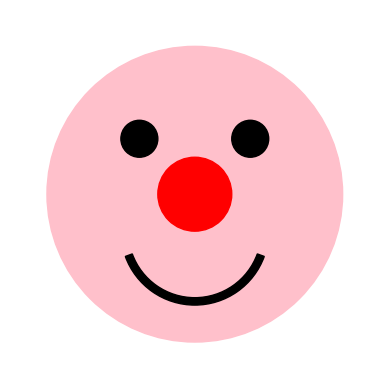

In [33]:
exec(function_call)

In [34]:
tools = [{
    "type": "function",
    "function": {
        "name": "draw_clown_face",
        "description": "Draws a custom clown face using matplotlib.",
        "parameters": {
            "type": "object",
            "properties": {
                "face_color": {"type": "string"},
                "eye_color": {"type": "string"},
                "nose_color": {"type": "string"}
            }
        }
    }
}]


In [41]:
def get_completion_from_messages(messages, tools,
                                 model="llama-3.3-70b-versatile",
                                 temperature=0, ):
    response = client.chat.completions.create(
        model=model,
        tools=tools,
        messages=messages,
        temperature=temperature, # this is the degree of randomness of the model's output
    )
    return response.choices[0].message.tool_calls[0]

In [42]:
import json
# Ask for a custom clown
messages = [{"role": "user", "content": "Draw a clown with a purple face"}]

# Step 1: Send to Groq
response = get_completion_from_messages(
    messages=messages,
    tools=tools)
print(response)


ChatCompletionMessageToolCall(id='w0aayypg5', function=Function(arguments='{"eye_color":"black","face_color":"purple","nose_color":"red"}', name='draw_clown_face'), type='function')


In [46]:
arguments = json.loads(response.function.arguments)
function= response.function.name
print(arguments)
print(function)

{'eye_color': 'black', 'face_color': 'purple', 'nose_color': 'red'}
draw_clown_face


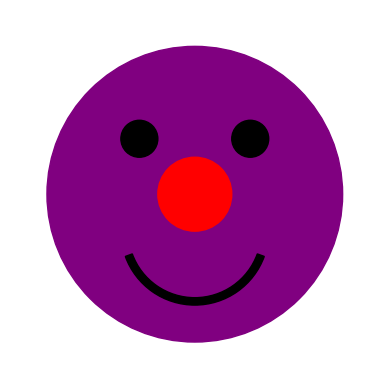

In [47]:
function_call = f'{function}(**{arguments})'
exec(function_call)